# Module Name: Neural and Evolutionary Systems 
# Module Code:  7031SCN<br>
## Course Work

### Task A

Assignment Task: <b> Artificial Neural Networks for Air Quality Classification</b><br>
Dataset: Beijing Multi-Site Air Quality (UCI Repository) <br>
Task: Multi-class classification of PM2.5 AQI categories<br>
Models: MLP | Deep Feedforward ANN | CNN-1D | LSTM<br>
Context: Classification of air quality based on the hourly air pollutant data from 12 nationally-controlled air-quality monitoring sites. The air-quality data are from the Beijing Municipal Environmental Monitoring Center. <br><br><br>


### Dataset variable information
No: row number <br>
year: year of data in this row <br>
month: month of data in this row <br>
day: day of data in this row <br>
hour: hour of data in this row <br>
PM2.5: PM2.5 concentration (ug/m^3)<br>
PM10: PM10 concentration (ug/m^3)<br>
SO2: SO2 concentration (ug/m^3)<br>
NO2: NO2 concentration (ug/m^3)<br>
CO: CO concentration (ug/m^3)<br>
O3: O3 concentration (ug/m^3)<br>
TEMP: temperature (degree Celsius) <br>
PRES: pressure (hPa)<br>
DEWP: dew point temperature (degree Celsius)<br>
RAIN: precipitation (mm)<br>
wd: wind direction<br>
WSPM: wind speed (m/s)<br>
station: name of the air-quality monitoring site<br>






# Importing necessary libraries for the task

In [1]:

import numpy as np
import pandas as pd
import os
import glob
import warnings
warnings.filterwarnings('ignore')

#For Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

#For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc )
from sklearn.utils.class_weight import compute_class_weight


#For ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten,
    LSTM, Input, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [2]:
#Setting random seeds for reproducability.
np.random.seed(22)
tf.random.set_seed(22)

# Importing Dataset

In [3]:
#Data of 12 cities are given in 12 different csv file so we need to find it and import
folder_path = r"C:\Users\vijayakumk\Downloads\beijing+multi+site+air+quality+data\PRSA_Data_20130301-20170228"

# Reading all the files in the folder
dfiles = glob.glob(os.path.join(folder_path, "*.csv"))
print(f"Found {len(dfiles)} csv files in the folder:")
for f in dfiles:
    print(f"  {os.path.basename(f)}")


Found 12 csv files in the folder:
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [4]:
#After importing the files we need to merge/concatenate all files into single file.
df_list = []
for f in dfiles:
    temp_file = pd.read_csv(f)
    df_list.append(temp_file)
 
df = pd.concat(df_list, ignore_index=True)


### Exploring the data

In [5]:
# Viewing the info on data
print("New dataset shape: ", df.shape)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")


New dataset shape:  (420768, 18)
Total rows: 420,768
Total columns: 18


In [6]:
df.head() #  top 5 data of the merged file

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [7]:
df.tail() #  last 5 data of the merged file

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


In [8]:
# This will give a basic understanding on the data type and the missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [9]:
# Further analysing on missing values.
print("\n--- Missing Values per Column ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


--- Missing Values per Column ---
       Missing Count  Missing %
PM2.5           8739   2.076916
PM10            6449   1.532674
SO2             9021   2.143937
NO2            12116   2.879497
CO             20701   4.919813
O3             13277   3.155421
TEMP             398   0.094589
PRES             393   0.093401
DEWP             403   0.095777
RAIN             390   0.092688
wd              1822   0.433018
WSPM             318   0.075576


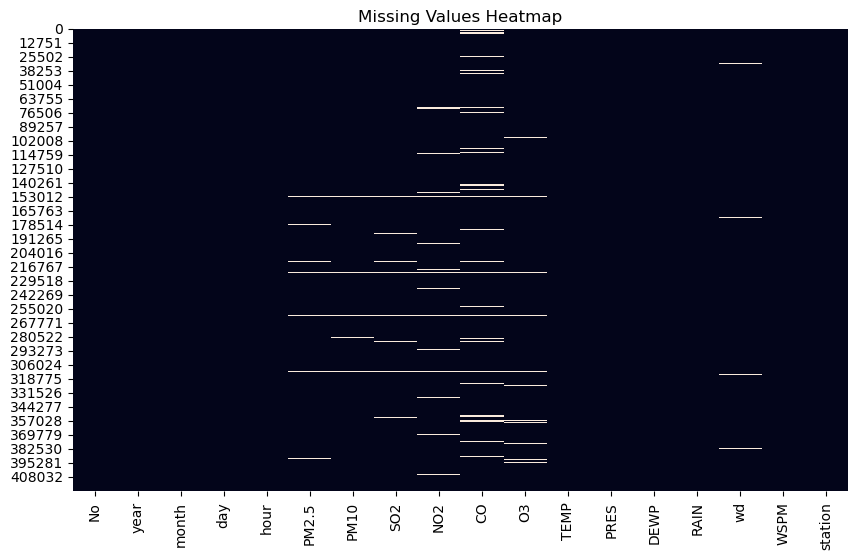

In [10]:
# A heatmap for missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

It reveals the presence of missing values across several attributes. For instance, approximately 2.08% of the PM2.5 values and 4.92% of CO values are missing. Such imperfections are common in real-world environmental datasets due to sensor malfunctions, transmission errors, or maintenance interruptions (Little & Rubin, 2019). Addressing these issues is essential to ensure the reliability and robustness of predictive models.

In [11]:
# Now lets summarise the data
print(df.describe())

                  No           year          month            day  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean    17532.500000    2014.662560       6.522930      15.729637   
std     10122.116943       1.177198       3.448707       8.800102   
min         1.000000    2013.000000       1.000000       1.000000   
25%      8766.750000    2014.000000       4.000000       8.000000   
50%     17532.500000    2015.000000       7.000000      16.000000   
75%     26298.250000    2016.000000      10.000000      23.000000   
max     35064.000000    2017.000000      12.000000      31.000000   

                hour          PM2.5           PM10            SO2  \
count  420768.000000  412029.000000  414319.000000  411747.000000   
mean       11.500000      79.793428     104.602618      15.830835   
std         6.922195      80.822391      91.772426      21.650603   
min         0.000000       2.000000       2.000000       0.285600   
25%         5.750000      20.0000

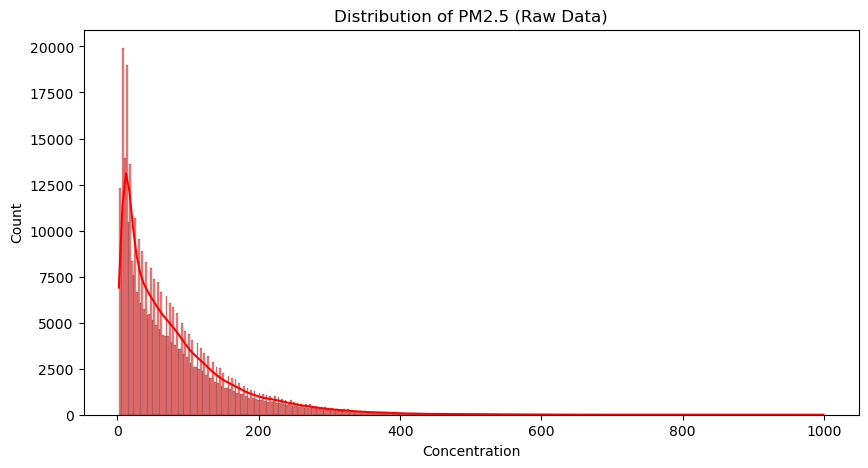

In [12]:
# Checking distribution of the main pollutant
plt.figure(figsize=(10, 5))
sns.histplot(df['PM2.5'].dropna(), kde=True, color='red')
plt.title('Distribution of PM2.5 (Raw Data)')
plt.xlabel('Concentration')
plt.show()

There is uneven distribution of PM2.5 concentration values, with a larger proportion of observations occurring at lower pollution levels and relatively fewer instances at extreme pollution levels. This imbalance can influence the learning process of classification models, potentially biasing them towards majority classes. 

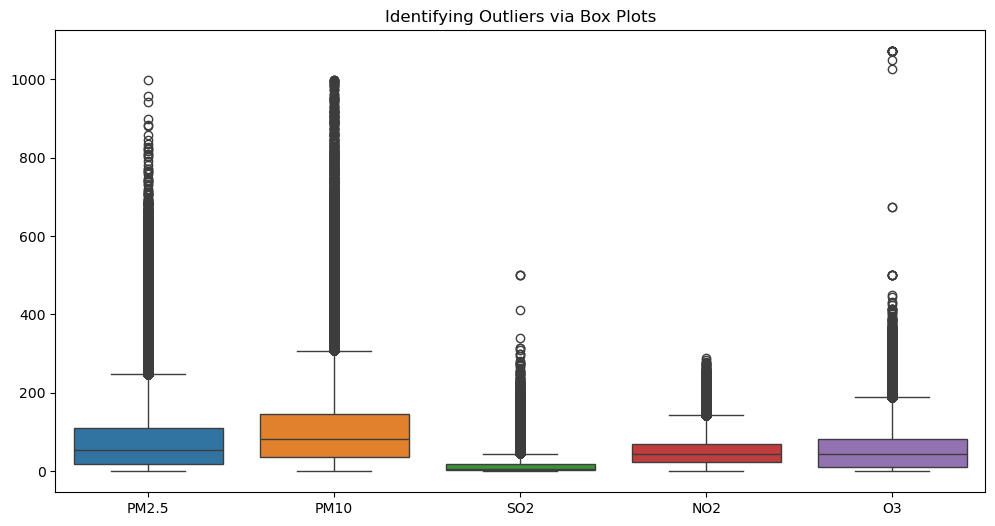

In [13]:
# Box plot to show outliers in pollutants
plt.figure(figsize=(12, 6))
features_to_plot = ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3']
sns.boxplot(data=df[features_to_plot])
plt.title('Identifying Outliers via Box Plots')
plt.show()

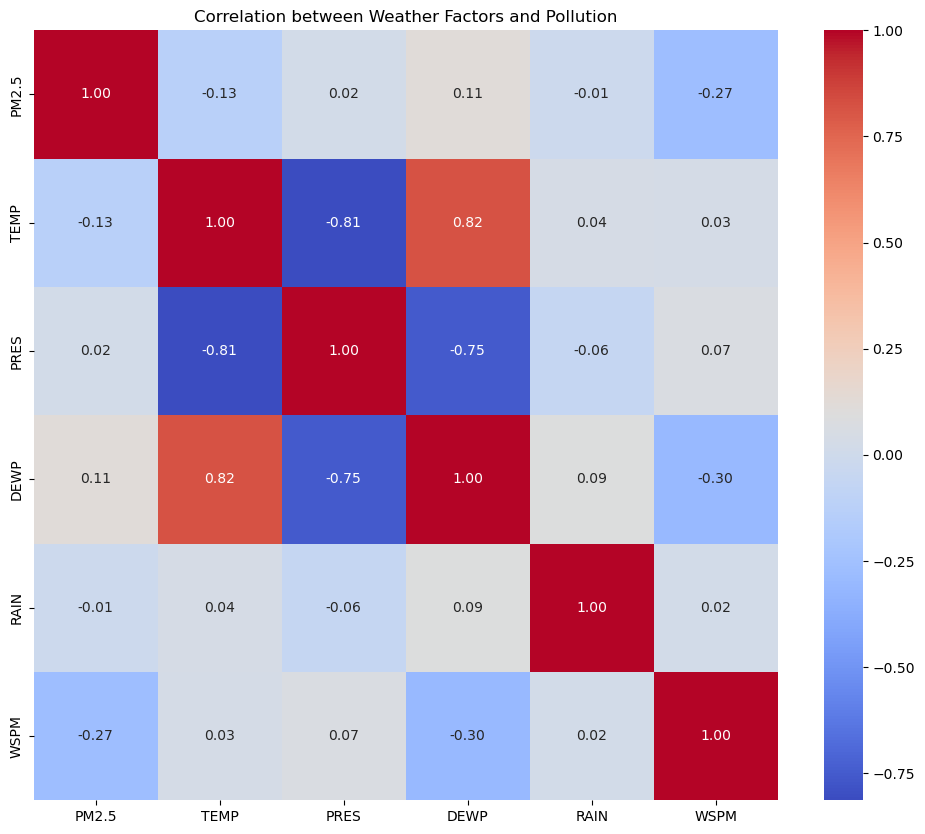

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Weather Factors and Pollution')
plt.show()

# Data Preprocessing

In [15]:
# Dropping the row_number column since no use with that

df.drop(columns=['No'], inplace=True)
print("Dropped 'No' column.")

Dropped 'No' column.


In [16]:
# We saw that PM2.5 column have 8739 missing values  that is 2.076916% so since it is our target column we can remove the null rows.
#  Drop rows where the TARGET (PM2.5) is missing since we cannot impute those values.
before = len(df)
df.dropna(subset=['PM2.5'], inplace=True)
after = len(df)
print(f"Dropped {before - after:,} rows with missing PM2.5. Remaining: {after:,}")

Dropped 8,739 rows with missing PM2.5. Remaining: 412,029


In [17]:
# Next we have to deal with the remaining feature values.
# Here we have the option to impute the values rather than removing them
# For the numeric columns we can fill with the median values that is robust to outliers.


numeric_cols = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
 
for col in numeric_cols:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    if n_missing > 0:
        print(f"  Imputed {n_missing:,} missing values in '{col}' with median ({median_val:.2f})")


  Imputed 216 missing values in 'PM10' with median (82.00)
  Imputed 3,698 missing values in 'SO2' with median (7.00)
  Imputed 6,747 missing values in 'NO2' with median (43.00)
  Imputed 15,162 missing values in 'CO' with median (900.00)
  Imputed 8,145 missing values in 'O3' with median (45.00)
  Imputed 398 missing values in 'TEMP' with median (14.40)
  Imputed 393 missing values in 'PRES' with median (1010.40)
  Imputed 403 missing values in 'DEWP' with median (3.00)
  Imputed 390 missing values in 'RAIN' with median (0.00)
  Imputed 317 missing values in 'WSPM' with median (1.40)


C:\Users\vijayakumk\AppData\Local\Temp\ipykernel_12484\3714875098.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [21]:
# for the Wind direction we can fill with the MODE (most frequent one).

wd_mode = df['wd'].mode()[0]
n_missing_wd = df['wd'].isnull().sum()
df['wd'].fillna(wd_mode, inplace=True)
print(f"  Imputed {n_missing_wd} missing 'wd' values with mode ('{wd_mode}')")
 
print(f"\nAfter imputation — remaining missing values: {df.isnull().sum().sum()}")

  Imputed 1797 missing 'wd' values with mode ('NE')

After imputation — remaining missing values: 0


C:\Users\vijayakumk\AppData\Local\Temp\ipykernel_12484\1535622644.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wd'].fillna(wd_mode, inplace=True)


Missing values were imputed using the median of each respective column. Median imputation was chosen over mean imputation due to the presence of outliers in pollution data, as indicated by the wide range of values observed in variables such as PM10 and CO. The median provides a more robust estimate in such cases and helps preserve the underlying distribution of the data.
Categorical missing values in the wind direction variable were handled using mode imputation, replacing missing entries with the most frequently occurring category. This approach ensures that the dominant wind pattern is retained without introducing unrealistic values.


### Feature Engineering

In [22]:
# Extract temporal features from year/month/day/hour columns.
# This capture seasonal and daily pollution patterns.
 
df['dayofyear'] = pd.to_datetime(
    df[['year', 'month', 'day']].rename(columns={'year':'year','month':'month','day':'day'})
).dt.dayofyear

To preserve the temporal relationship of cyclical features, we transformed 'hour' and 'month' into 2D coordinates using sine and cosine transformations. This prevents the Artificial Neural Network from misinterpreting the natural continuity of time—ensuring, for instance, that the model recognizes the proximity between 11:00 PM and 12:00 AM, which would otherwise be treated as mathematically distant in a linear 0–23 scale.

In [24]:
# Cyclical encoding of hour and month (so hour 23 is close to hour 0)
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
print("Added cyclical time features: hour_sin, hour_cos, month_sin, month_cos")


Added cyclical time features: hour_sin, hour_cos, month_sin, month_cos


In [26]:
# Now since the wind direction is in categorical form we have to change numerical form

enc_wd = LabelEncoder()
df['wd_encoded'] = enc_wd.fit_transform(df['wd'])
print(f"Encoded 'wd' into integers. Unique directions: {df['wd'].nunique()}")

Encoded 'wd' into integers. Unique directions: 16


In [28]:
# Now we have to encode the 12 different station to numerical format
enc_station = LabelEncoder()
df['station_encoded'] = enc_station.fit_transform(df['station'])
print(f"Encoded 'station' into integers. Stations: {df['station'].nunique()}")

Encoded 'station' into integers. Stations: 12


In [29]:
# Now since the target variable PM2.5 is in numerical format we have to classify them based on 
# China National Ambient Air Quality Standard (GB 3095-2012):
#   Class 0 — Excellent:          PM2.5 ≤ 35 µg/m³
#   Class 1 — Good:               35 < PM2.5 ≤ 75
#   Class 2 — Light Pollution:    75 < PM2.5 ≤ 115
#   Class 3 — Moderate Pollution: 115 < PM2.5 ≤ 150
#   Class 4 — Heavy Pollution:    150 < PM2.5 ≤ 250
#   Class 5 — Severe Pollution:   PM2.5 > 250

bins   = [0, 35, 75, 115, 150, 250, np.inf]
labels = [0,  1,  2,   3,   4,   5]
label_names = ['Excellent', 'Good', 'Light Pollution',
               'Moderate Pollution', 'Heavy Pollution', 'Severe Pollution']
 
df['AQI_class'] = pd.cut(df['PM2.5'], bins=bins, labels=labels, right=True).astype(int)
 
print("\nAQI Class distribution:")
for i, name in enumerate(label_names):
    n = (df['AQI_class'] == i).sum()
    pct = n / len(df) * 100
    print(f"  Class {i} ({name}): {n:,} rows ({pct:.1f}%)")


AQI Class distribution:
  Class 0 (Excellent): 153,871 rows (37.3%)
  Class 1 (Good): 97,156 rows (23.6%)
  Class 2 (Light Pollution): 63,782 rows (15.5%)
  Class 3 (Moderate Pollution): 34,550 rows (8.4%)
  Class 4 (Heavy Pollution): 44,234 rows (10.7%)
  Class 5 (Severe Pollution): 18,436 rows (4.5%)


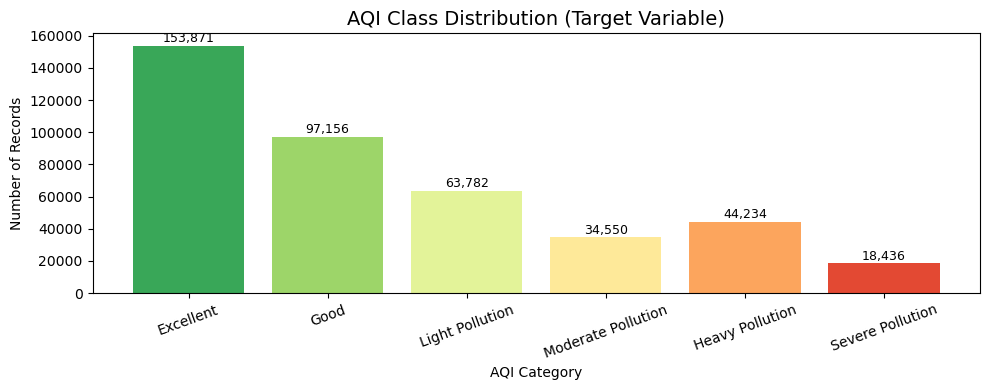

In [30]:
# We can visualise the class distribution


# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 4))
counts = df['AQI_class'].value_counts().sort_index()
bars = ax.bar(label_names, counts.values, color=sns.color_palette("RdYlGn_r", 6))
ax.set_title("AQI Class Distribution (Target Variable)", fontsize=14)
ax.set_xlabel("AQI Category")
ax.set_ylabel("Number of Records")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plot_03_class_distribution.png", dpi=150)
plt.show()

# Data Preparation and Splitting


In [32]:
# Now lets prepare the feature columns and target column
# Selecting the cleaned feature columns and target values.
FEATURE_COLS = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',          # Pollutant features
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',     # Meteorological features
    'wd_encoded', 'station_encoded',             # Categorical encoded
    'hour_sin', 'hour_cos',                      # Cyclical hour
    'month_sin', 'month_cos',                    # Cyclical month
    'dayofyear'                                  # Day of year
]

TARGET_COL = 'AQI_class'
NUM_CLASSES = 6
 
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values
 
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")
print(f"Features used: {FEATURE_COLS}")

Feature matrix X shape: (412029, 17)
Target vector y shape:  (412029,)
Features used: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_encoded', 'station_encoded', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear']


In [33]:
# Splitting the data into Train,Validation and Test in 70%,15%,15% manner

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
 
print(f"\nTrain:      {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,}  rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.1f}%)")


Train:      288,420 rows (70.0%)
Validation: 61,804  rows (15.0%)
Test:       61,805  rows (15.0%)


In [34]:
# Now lets scale the data
# Currently doing StandardScaler() only on training data to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
 
print("\nFeatures scaled with StandardScaler (zero mean, unit variance).")




Features scaled with StandardScaler (zero mean, unit variance).


In [35]:
# One-hot encode labels for categorical cross-entropy loss
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

In [36]:
# Now lets compute class weights to handle class imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("\nClass weights (to handle imbalance):")
for k, v in class_weight_dict.items():
    print(f"  Class {k} ({label_names[k]}): {v:.3f}")


Class weights (to handle imbalance):
  Class 0 (Excellent): 0.446
  Class 1 (Good): 0.707
  Class 2 (Light Pollution): 1.077
  Class 3 (Moderate Pollution): 1.988
  Class 4 (Heavy Pollution): 1.552
  Class 5 (Severe Pollution): 3.725


In [37]:
# Input shape for all dense models
N_FEATURES = X_train_s.shape[1]  # = 17

### Function definition for clean and clear comparison and evaluation for multiple models


In [38]:

def plot_training_history(history, model_name):
    """Plot training and validation loss & accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
    axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral')
    axes[0].set_title(f"{model_name} — Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Categorical Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
 
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral')
    axes[1].set_title(f"{model_name} — Accuracy Curves")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    plt.savefig(f"plot_training_{safe_name}.png", dpi=150)
    plt.show()
 
 
def evaluate_model(model, X_test_scaled, y_test_int, y_test_onehot, model_name):
    """
    Evaluate a trained model on the test set.
    Returns a dict of metrics and prints a full report.
    """
    # Predictions
    y_pred_prob = model.predict(X_test_scaled, verbose=0)   # shape (n, 6)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)
 
    # Overall accuracy
    accuracy = np.mean(y_pred_int == y_test_int)
 
    # Per-class precision, recall, F1
    report = classification_report(
        y_test_int, y_pred_int,
        target_names=label_names,
        output_dict=True
    )
    macro_f1       = report['macro avg']['f1-score']
    weighted_f1    = report['weighted avg']['f1-score']
 
    # ROC-AUC (one-vs-rest, macro average)
    roc_auc = roc_auc_score(y_test_onehot, y_pred_prob,
                            multi_class='ovr', average='macro')
 
    print(f"\n{'='*60}")
    print(f"  EVALUATION REPORT — {model_name}")
    print(f"{'='*60}")
    print(f"  Test Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1-Score:       {macro_f1:.4f}")
    print(f"  Weighted F1-Score:    {weighted_f1:.4f}")
    print(f"  ROC-AUC (macro OvR):  {roc_auc:.4f}")
    print(f"\n{classification_report(y_test_int, y_pred_int, target_names=label_names)}")
 
    # Confusion Matrix
    cm = confusion_matrix(y_test_int, y_pred_int)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    plt.savefig(f"plot_cm_{safe_name}.png", dpi=150)
    plt.show()
 
    return {
        'model': model_name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'roc_auc': roc_auc,
        'y_pred_prob': y_pred_prob,
        'y_pred_int': y_pred_int
    }
 
 
# Shared callbacks used by all models
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

# Building the ANN model

#### MODEL 1 — SHALLOW MLP (Baseline)


MODEL 1: Shallow MLP (Baseline)


C:\Users\vijayakumk\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Shallow_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 64)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,430 (13.40 KB)

 Trainable params: 3,430 (13.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5655 - loss: 1.0819 - val_accuracy: 0.7096 - val_loss: 0.7144 - learning_rate: 0.0010
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6820 - loss: 0.8271 - val_accuracy: 0.7311 - val_loss: 0.6559 - learning_rate: 0.0010
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7001 - loss: 0.7806 - val_accuracy: 0.7363 - val_loss: 0.6390 - learning_rate: 0.0010
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7099 - loss: 0.7570 - val_accuracy: 0.7383 - val_loss: 0.6301 - learning_rate: 0.0010
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7149 - loss: 0.7452 - val_accuracy: 0.7402 - val_loss: 0.6242 - learning_rate: 0.0010
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7184 - loss: 0.7360 - val_accuracy: 0.7433 - val_loss: 0.6174 - learning_rate: 0.0010
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7224 - loss: 0.

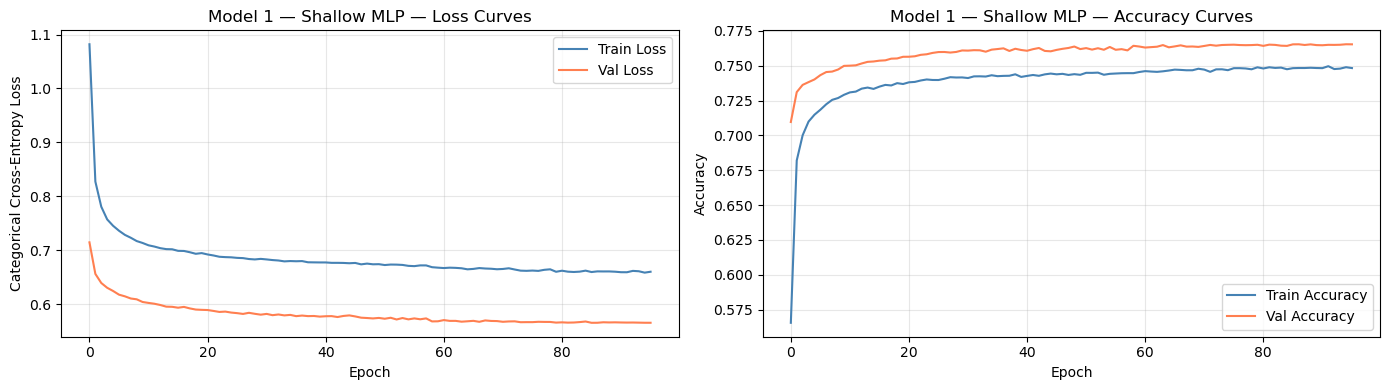


  EVALUATION REPORT — Model 1 — Shallow MLP
  Test Accuracy:        0.7677 (76.77%)
  Macro F1-Score:       0.7359
  Weighted F1-Score:    0.7707
  ROC-AUC (macro OvR):  0.9578

                    precision    recall  f1-score   support

         Excellent       0.94      0.87      0.91     23081
              Good       0.71      0.72      0.72     14574
   Light Pollution       0.63      0.62      0.63      9568
Moderate Pollution       0.52      0.63      0.57      5182
   Heavy Pollution       0.77      0.74      0.76      6635
  Severe Pollution       0.76      0.93      0.84      2765

          accuracy                           0.77     61805
         macro avg       0.72      0.75      0.74     61805
      weighted avg       0.78      0.77      0.77     61805



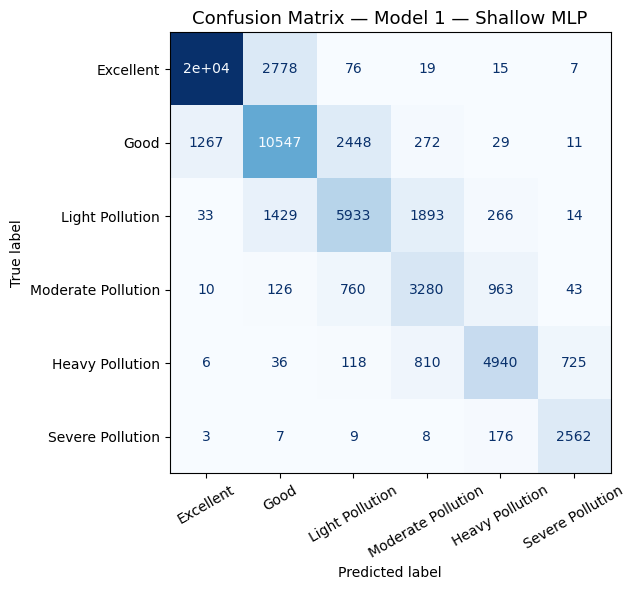

In [39]:
# Architecture:
#   Input (17) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU)
#   → Dropout(0.2) → Dense(6, Softmax)
print("\n" + "="*60)
print("MODEL 1: Shallow MLP (Baseline)")
print("="*60)
 
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(N_FEATURES,), name='hidden_1'),
    Dropout(0.3),
    Dense(32, activation='relu', name='hidden_2'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='Shallow_MLP')
 
model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
 
model1.summary()
 
history1 = model1.fit(
    X_train_s, y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
 
plot_training_history(history1, "Model 1 — Shallow MLP")
results1 = evaluate_model(model1, X_test_s, y_test, y_test_cat, "Model 1 — Shallow MLP")

#### MODEL 2 — DEEP FEEDFORWARD ANN WITH BATCH NORMALISATION

In [40]:
# Architecture:
#   Input (17) → [Dense(256) → BN → ReLU → Dropout(0.4)] ×
#                [Dense(128) → BN → ReLU → Dropout(0.3)] ×
#                [Dense(64)  → BN → ReLU → Dropout(0.2)] ×
#                [Dense(32)  → BN → ReLU] →
#   Dense(6, Softmax)


print("\n" + "="*60)
print("MODEL 2: Deep Feedforward ANN with Batch Normalisation")
print("="*60)
 
model2 = Sequential([
    Dense(256, input_shape=(N_FEATURES,), name='hidden_1'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.4),
 
    Dense(128, name='hidden_2'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),
 
    Dense(64, name='hidden_3'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.2),
 
    Dense(32, name='hidden_4'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
 
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='Deep_Feedforward_BN')
 

 




MODEL 2: Deep Feedforward ANN with Batch Normalisation


C:\Users\vijayakumk\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model2.summary()

Model: "Deep_Feedforward_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 256)                 │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_3 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_4 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,958 (195.15 KB)

 Trainable params: 48,998 (191.40 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6332 - loss: 0.9466 - val_accuracy: 0.7292 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7058 - loss: 0.7613 - val_accuracy: 0.7406 - val_loss: 0.6216 - learning_rate: 0.0010
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7139 - loss: 0.7364 - val_accuracy: 0.7413 - val_loss: 0.6156 - learning_rate: 0.0010
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7189 - loss: 0.7221 - val_accuracy: 0.7419 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7229 - loss: 0.7123 - val_accuracy: 0.7455 - val_loss: 0.6017 - learning_rate: 0.0010
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7251 - loss: 0.7035 - val_accuracy: 0.7505 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7289 - loss: 0

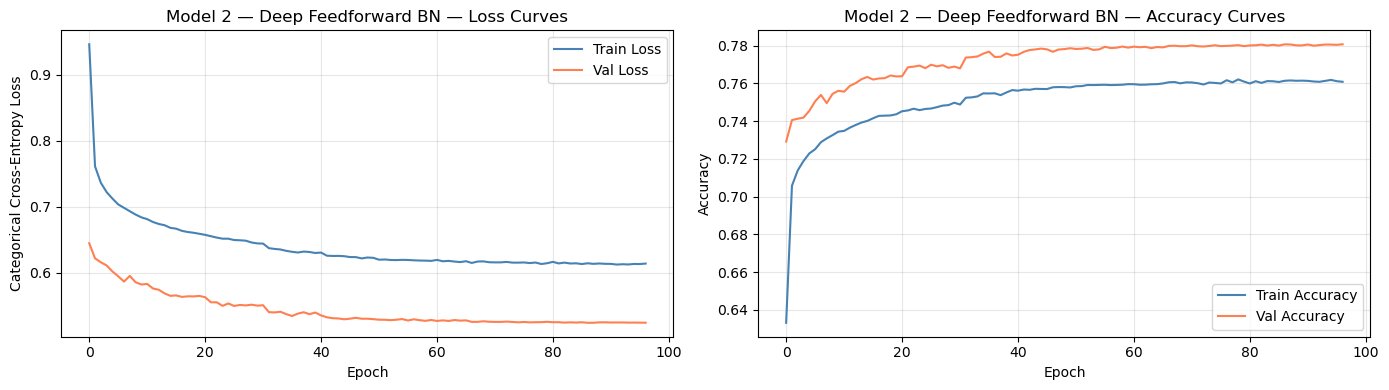


  EVALUATION REPORT — Model 2 — Deep Feedforward BN
  Test Accuracy:        0.7834 (78.34%)
  Macro F1-Score:       0.7579
  Weighted F1-Score:    0.7877
  ROC-AUC (macro OvR):  0.9640

                    precision    recall  f1-score   support

         Excellent       0.95      0.87      0.91     23081
              Good       0.73      0.74      0.73     14574
   Light Pollution       0.65      0.66      0.66      9568
Moderate Pollution       0.53      0.72      0.61      5182
   Heavy Pollution       0.82      0.75      0.78      6635
  Severe Pollution       0.80      0.92      0.86      2765

          accuracy                           0.78     61805
         macro avg       0.75      0.78      0.76     61805
      weighted avg       0.80      0.78      0.79     61805



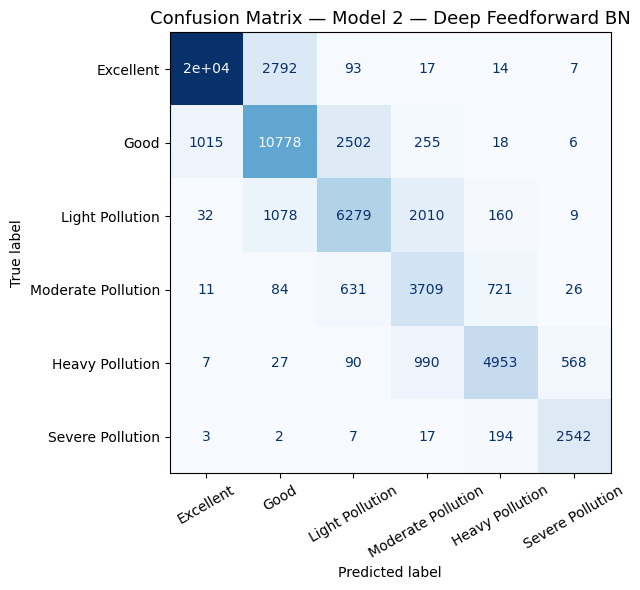

In [43]:
 
history2 = model2.fit(
    X_train_s, y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
 
plot_training_history(history2, "Model 2 — Deep Feedforward BN")
results2 = evaluate_model(model2, X_test_s, y_test, y_test_cat, "Model 2 — Deep Feedforward BN")

#### MODEL 3 — 1D CONVOLUTIONAL NEURAL NETWORK (CNN-1D)

In [44]:
# Architecture:
#   Input (17,1) → Conv1D(64, kernel=3, ReLU) → Conv1D(128, kernel=3, ReLU)
#   → MaxPooling1D(2) → Flatten → Dense(64, ReLU) → Dropout(0.3)
#   → Dense(6, Softmax)
print("\n" + "="*60)
print("MODEL 3: 1D Convolutional Neural Network (CNN-1D)")
print("="*60)
 
# Reshape data to (samples, timesteps, 1) for Conv1D
X_train_cnn = X_train_s.reshape(X_train_s.shape[0], N_FEATURES, 1)
X_val_cnn   = X_val_s.reshape(X_val_s.shape[0],   N_FEATURES, 1)
X_test_cnn  = X_test_s.reshape(X_test_s.shape[0],  N_FEATURES, 1)
 
model3 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           padding='same', input_shape=(N_FEATURES, 1), name='conv_1'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=3, activation='relu',
           padding='same', name='conv_2'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2, name='pool_1'),
    Dropout(0.3),
 
    Conv1D(filters=64, kernel_size=2, activation='relu',
           padding='same', name='conv_3'),
    Flatten(name='flatten'),
 
    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='CNN_1D')


MODEL 3: 1D Convolutional Neural Network (CNN-1D)


C:\Users\vijayakumk\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
model3.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_1 (Conv1D)                      │ (None, 17, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 17, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv1D)                      │ (None, 17, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 17, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool_1 (MaxPooling1D)                │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_3 (Conv1D)                      │ (None, 8, 64)               │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,398 (294.52 KB)

 Trainable params: 75,014 (293.02 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6714 - loss: 0.8519 - val_accuracy: 0.7363 - val_loss: 0.6267 - learning_rate: 0.0010
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.7202 - loss: 0.7258 - val_accuracy: 0.7521 - val_loss: 0.5923 - learning_rate: 0.0010
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.7307 - loss: 0.6958 - val_accuracy: 0.7584 - val_loss: 0.5763 - learning_rate: 0.0010
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.7371 - loss: 0.6776 - val_accuracy: 0.7649 - val_loss: 0.5616 - learning_rate: 0.0010
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.7426 - loss: 0.6645 - val_accuracy: 0.7626 - val_loss: 0.5611 - learning_rate: 0.0010
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.7450 - loss: 0.6556 - val_accuracy: 0.7655 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.7

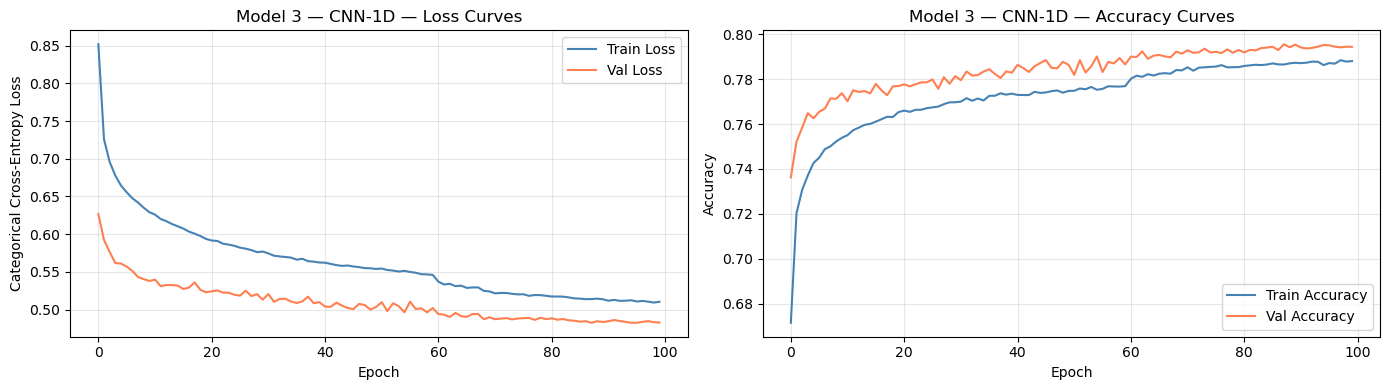

In [47]:
history3 = model3.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
 
plot_training_history(history3, "Model 3 — CNN-1D")


  EVALUATION REPORT — Model 3 — CNN-1D
  Test Accuracy:        0.7979 (79.79%)
  Macro F1-Score:       0.7774
  Weighted F1-Score:    0.8013
  ROC-AUC (macro OvR):  0.9686

                    precision    recall  f1-score   support

         Excellent       0.95      0.88      0.92     23081
              Good       0.75      0.74      0.74     14574
   Light Pollution       0.66      0.68      0.67      9568
Moderate Pollution       0.57      0.72      0.64      5182
   Heavy Pollution       0.84      0.79      0.82      6635
  Severe Pollution       0.83      0.95      0.88      2765

          accuracy                           0.80     61805
         macro avg       0.77      0.79      0.78     61805
      weighted avg       0.81      0.80      0.80     61805



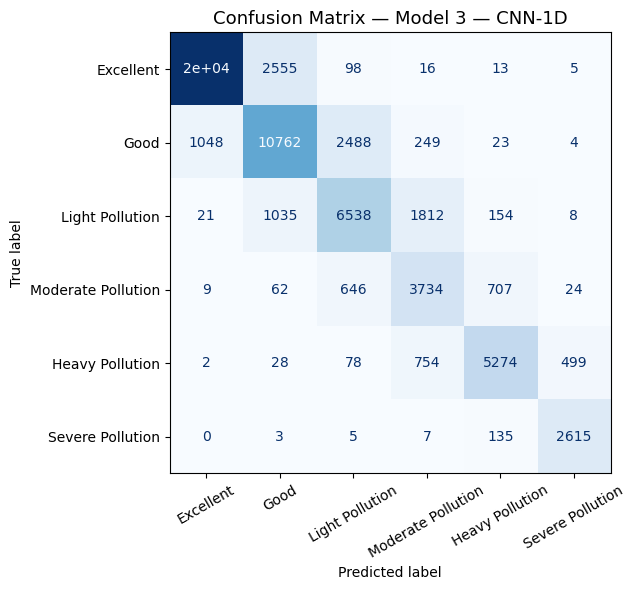

In [48]:
# CNN evaluation uses reshaped test set
def evaluate_model_cnn(model, X_test_scaled, y_test_int, y_test_onehot, model_name):
    y_pred_prob = model.predict(X_test_scaled, verbose=0)
    y_pred_int  = np.argmax(y_pred_prob, axis=1)
    accuracy    = np.mean(y_pred_int == y_test_int)
    report      = classification_report(y_test_int, y_pred_int,
                                        target_names=label_names, output_dict=True)
    macro_f1    = report['macro avg']['f1-score']
    weighted_f1 = report['weighted avg']['f1-score']
    roc_auc     = roc_auc_score(y_test_onehot, y_pred_prob,
                                multi_class='ovr', average='macro')
    print(f"\n{'='*60}")
    print(f"  EVALUATION REPORT — {model_name}")
    print(f"{'='*60}")
    print(f"  Test Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1-Score:       {macro_f1:.4f}")
    print(f"  Weighted F1-Score:    {weighted_f1:.4f}")
    print(f"  ROC-AUC (macro OvR):  {roc_auc:.4f}")
    print(f"\n{classification_report(y_test_int, y_pred_int, target_names=label_names)}")
    cm = confusion_matrix(y_test_int, y_pred_int)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
        ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"plot_cm_{model_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    return {'model': model_name, 'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'roc_auc': roc_auc,
            'y_pred_prob': y_pred_prob, 'y_pred_int': y_pred_int}
 
results3 = evaluate_model_cnn(model3, X_test_cnn, y_test, y_test_cat, "Model 3 — CNN-1D")

#### MODEL 4 — LSTM (LONG SHORT-TERM MEMORY)

In [49]:
# Architecture:
#   Input (17,1) → LSTM(128, return_sequences=True) → Dropout(0.3)
#   → LSTM(64) → Dropout(0.3) → Dense(32, ReLU) → Dense(6, Softmax)
 
print("\n" + "="*60)
print("MODEL 4: LSTM (Long Short-Term Memory)")
print("="*60)
 
# Reusing the same CNN reshape (samples, timesteps=17, features=1)
X_train_lstm = X_train_cnn
X_val_lstm   = X_val_cnn
X_test_lstm  = X_test_cnn
 
model4 = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(N_FEATURES, 1), name='lstm_1'),
    Dropout(0.3),
    LSTM(64, return_sequences=False, name='lstm_2'),
    Dropout(0.3),
    Dense(32, activation='relu', name='dense_1'),
    BatchNormalization(),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='LSTM_Model')


MODEL 4: LSTM (Long Short-Term Memory)


C:\Users\vijayakumk\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
model4.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 17, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 17, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,374 (462.40 KB)

 Trainable params: 118,310 (462.15 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 54s 88ms/step - accuracy: 0.5569 - loss: 1.1024 - val_accuracy: 0.5484 - val_loss: 1.1442 - learning_rate: 0.0010
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.6280 - loss: 0.9029 - val_accuracy: 0.6286 - val_loss: 0.8708 - learning_rate: 0.0010
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.6491 - loss: 0.8528 - val_accuracy: 0.6371 - val_loss: 0.8454 - learning_rate: 0.0010
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 52s 92ms/step - accuracy: 0.6569 - loss: 0.8259 - val_accuracy: 0.6463 - val_loss: 0.8202 - learning_rate: 0.0010
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.6683 - loss: 0.7972 - val_accuracy: 0.6773 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.6947 - loss: 0.7604 - val_accuracy: 0.7015 - val_loss: 0.7046 - learning_rate: 0.0010
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 51s 90ms/step - accuracy: 0.7

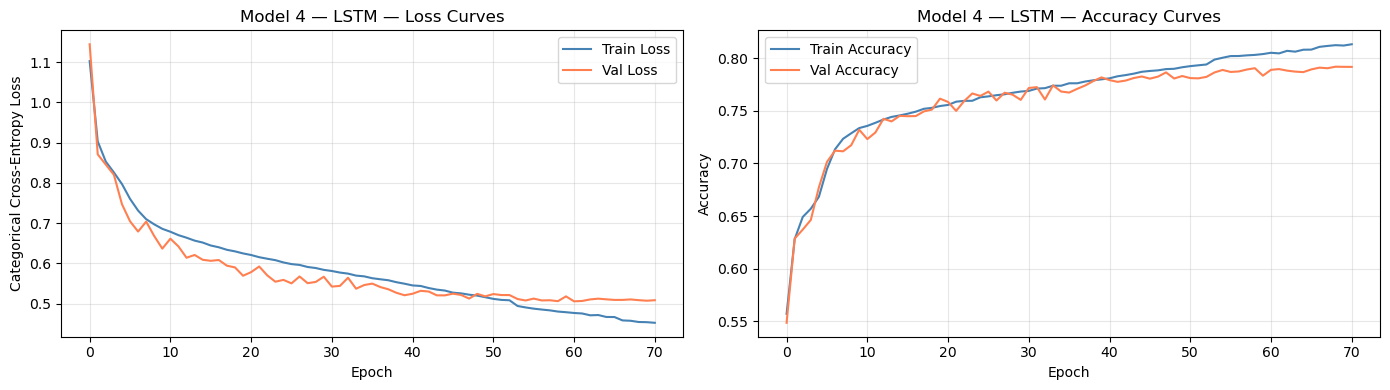


  EVALUATION REPORT — Model 4 — LSTM
  Test Accuracy:        0.7930 (79.30%)
  Macro F1-Score:       0.7715
  Weighted F1-Score:    0.7971
  ROC-AUC (macro OvR):  0.9662

                    precision    recall  f1-score   support

         Excellent       0.95      0.88      0.91     23081
              Good       0.73      0.75      0.74     14574
   Light Pollution       0.67      0.67      0.67      9568
Moderate Pollution       0.55      0.72      0.62      5182
   Heavy Pollution       0.82      0.78      0.80      6635
  Severe Pollution       0.87      0.88      0.88      2765

          accuracy                           0.79     61805
         macro avg       0.77      0.78      0.77     61805
      weighted avg       0.80      0.79      0.80     61805



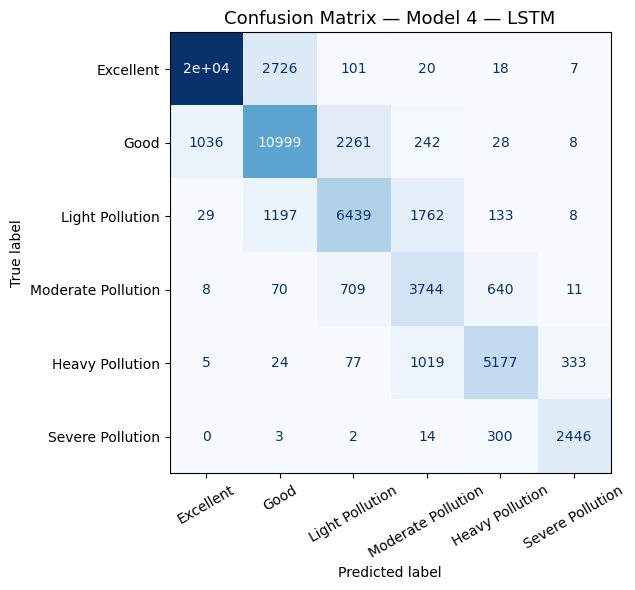

In [52]:
history4 = model4.fit(
    X_train_lstm, y_train_cat,
    validation_data=(X_val_lstm, y_val_cat),
    epochs=100,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1
)
 
plot_training_history(history4, "Model 4 — LSTM")
results4 = evaluate_model_cnn(model4, X_test_lstm, y_test, y_test_cat, "Model 4 — LSTM")

### COMPARISON

In [53]:
#Collecting all results into a summary table and produce a comparison chart.
all_results = [results1, results2, results3, results4]
metrics_df = pd.DataFrame([
    {
        'Model':       r['model'],
        'Accuracy':    round(r['accuracy'],    4),
        'Macro F1':    round(r['macro_f1'],    4),
        'Weighted F1': round(r['weighted_f1'], 4),
        'ROC-AUC':     round(r['roc_auc'],     4),
    }
    for r in all_results
])
 
print("\n" + "="*70)
print("  FINAL MODEL COMPARISON")
print("="*70)
print(metrics_df.to_string(index=False))
print("="*70)


  FINAL MODEL COMPARISON
                        Model  Accuracy  Macro F1  Weighted F1  ROC-AUC
        Model 1 — Shallow MLP    0.7677    0.7359       0.7707   0.9578
Model 2 — Deep Feedforward BN    0.7834    0.7579       0.7877   0.9640
             Model 3 — CNN-1D    0.7979    0.7774       0.8013   0.9686
               Model 4 — LSTM    0.7930    0.7715       0.7971   0.9662


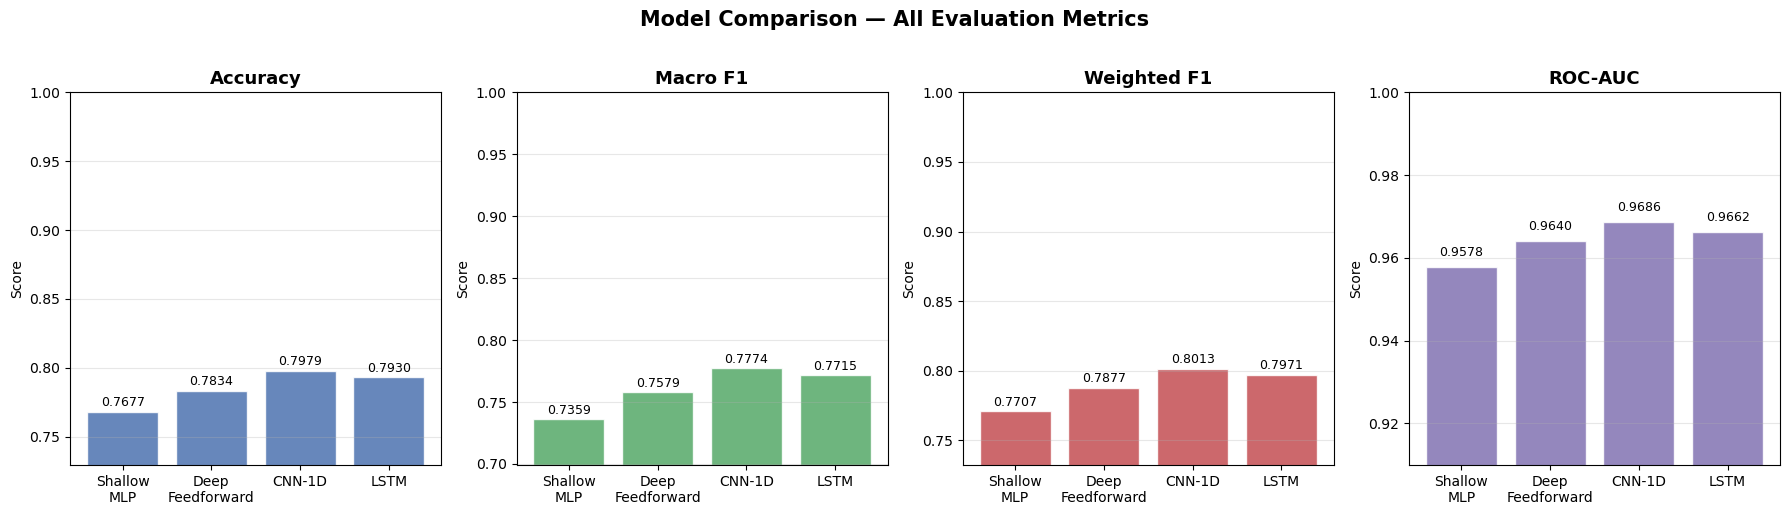

In [54]:
# Bar chart comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_list = ['Accuracy', 'Macro F1', 'Weighted F1', 'ROC-AUC']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
short_names = ['Shallow\nMLP', 'Deep\nFeedforward', 'CNN-1D', 'LSTM']
 
for ax, metric, color in zip(axes, metrics_list, colors):
    vals = metrics_df[metric].values
    bars = ax.bar(short_names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(min(vals) * 0.95, 1.0)
    ax.set_ylabel("Score")
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
 
plt.suptitle("Model Comparison — All Evaluation Metrics", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_final_comparison.png", dpi=150)
plt.show()

#### ROC CURVES FOR THE BEST MODEL

In [55]:
# Find the best model by ROC-AUC
best_idx = metrics_df['ROC-AUC'].idxmax()
best_result = all_results[best_idx]
best_name   = best_result['model']
 
print(f"\nBest model by ROC-AUC: {best_name}")


Best model by ROC-AUC: Model 3 — CNN-1D


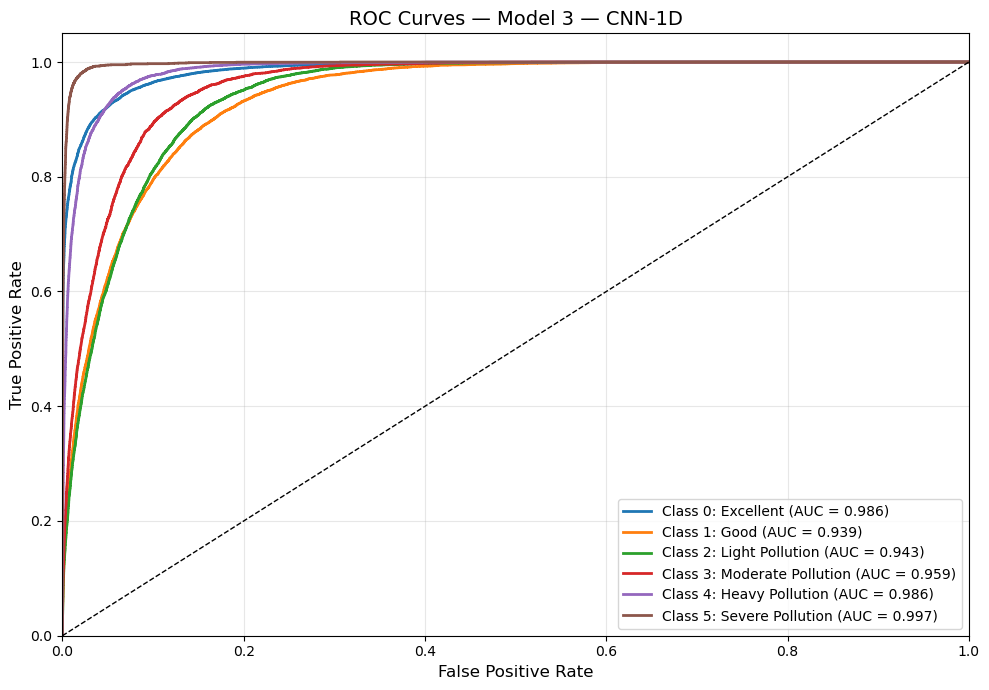

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = sns.color_palette("tab10", NUM_CLASSES)
 
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], best_result['y_pred_prob'][:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
            label=f"Class {i}: {label_names[i]} (AUC = {roc_auc_i:.3f})")
 
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves — {best_name}", fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot_roc_best_model.png", dpi=150)
plt.show()

#### Conclusion

In [58]:
print("\n" + "="*70)
print("  CONCLUSION")
print("="*70)
best_row = metrics_df.loc[best_idx]
print(f"""
  Best performing model: {best_row['Model']}
 
  Performance summary:
    Accuracy:    {best_row['Accuracy']:.4f} ({best_row['Accuracy']*100:.2f}%)
    Macro F1:    {best_row['Macro F1']:.4f}
    Weighted F1: {best_row['Weighted F1']:.4f}
    ROC-AUC:     {best_row['ROC-AUC']:.4f}
 
  Why this model performed best:
  
  - Model 3 (CNN-1D) captures local feature interactions through
    convolutional filters.
  
 




 
""")
 
print("All plots saved to the current directory.")
print("Files saved: plot_01 to plot_final_comparison, plot_roc_best_model")


  CONCLUSION

  Best performing model: Model 3 — CNN-1D
 
  Performance summary:
    Accuracy:    0.7979 (79.79%)
    Macro F1:    0.7774
    Weighted F1: 0.8013
    ROC-AUC:     0.9686
 
  Why this model performed best:
  
  - Model 3 (CNN-1D) captures local feature interactions through
    convolutional filters.
  
 
 

All plots saved to the current directory.
Files saved: plot_01 to plot_final_comparison, plot_roc_best_model
